# 🛍️ Retail Customer Satisfaction Insights

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Preparation

In [27]:
df = pd.read_csv("customer_satisfaction_data.csv")

print(df.head())
print(df.info())

  Survey_ID Customer_ID Store_Location  Visit_Date  Purchase_Amount  \
0      S001       C1001         Mumbai  2025-06-13          1935.25   
1      S002       C1002      Ahmedabad  2025-01-27          4758.50   
2      S003       C1003           Pune  2025-01-08          3686.77   
3      S004       C1004           Pune  2025-02-20          3033.43   
4      S005       C1005         Mumbai  2025-03-13           864.49   

   Wait_Time_Min  Staff_Rating  Product_Rating  Cleanliness_Rating Recommend  \
0              8             1               3                   2       Yes   
1             44             5               1                   5        No   
2              6             2               2                   5       Yes   
3             42             5               4                   2        No   
4              1             2               4                   3        No   

   Total_Rating  
0           2.0  
1           3.7  
2           3.0  
3           3.7  
4 

### Convert Visit_Date into datetime format and extract Month and Weekday.

In [28]:
df["Visit_Date"] = pd.to_datetime(df["Visit_Date"])

df["Month"] = df["Visit_Date"].dt.month_name()

df["Weekday"] =  df["Visit_Date"].dt.day_name()

df.head()

,Survey_ID,Customer_ID,Store_Location,Visit_Date,Purchase_Amount,Wait_Time_Min,Staff_Rating,Product_Rating,Cleanliness_Rating,Recommend,Total_Rating,Month,Weekday
0,S001,C1001,Mumbai,2025-06-13,1935.25,8,1,3,2,Yes,2.0,June,Friday
1,S002,C1002,Ahmedabad,2025-01-27,4758.50,44,5,1,5,No,3.7,January,Monday
2,S003,C1003,Pune,2025-01-08,3686.77,6,2,2,5,Yes,3.0,January,Wednesday
3,S004,C1004,Pune,2025-02-20,3033.43,42,5,4,2,No,3.7,February,Thursday
4,S005,C1005,Mumbai,2025-03-13,864.49,1,2,4,3,No,3.0,March,Thursday


### Replace Ratings with Categories

In [29]:
def rating_category(x):
    if x <= 2:
        return "Low"
    elif x <= 4:
        return "Medium"
    else:
        return "High"

df["Staff_Category"] =  df["Staff_Rating"].apply(rating_category)
df["Product_Category"] =  df["Product_Rating"].apply(rating_category)
df["Cleanliness_Category"] =  df["Cleanliness_Rating"].apply(rating_category)

df.head()

,Survey_ID,Customer_ID,Store_Location,Visit_Date,Purchase_Amount,Wait_Time_Min,Staff_Rating,Product_Rating,Cleanliness_Rating,Recommend,Total_Rating,Month,Weekday,Staff_Category,Product_Category,Cleanliness_Category
0,S001,C1001,Mumbai,2025-06-13,1935.25,8,1,3,2,Yes,2.0,June,Friday,Low,Medium,Low
1,S002,C1002,Ahmedabad,2025-01-27,4758.50,44,5,1,5,No,3.7,January,Monday,High,Low,High
2,S003,C1003,Pune,2025-01-08,3686.77,6,2,2,5,Yes,3.0,January,Wednesday,Low,Low,High
3,S004,C1004,Pune,2025-02-20,3033.43,42,5,4,2,No,3.7,February,Thursday,High,Medium,Low
4,S005,C1005,Mumbai,2025-03-13,864.49,1,2,4,3,No,3.0,March,Thursday,Low,Medium,Medium


## Data Analysis

### Calculate average Total_Rating by Store_Location.

In [30]:
avg_rating = df.groupby("Store_Location")["Total_Rating"].mean()

print(avg_rating)

Store_Location
Ahmedabad    3.262963
Bangalore    3.184615
Delhi        2.844444
Mumbai       2.744000
Pune         3.121875
Name: Total_Rating, dtype: float64


### Correlation Between Wait Time and Purchase Amount

In [31]:
correlation = df["Wait_Time_Min"].corr(df["Purchase_Amount"])

print(correlation)

-0.05859030796452665


### Total Purchases by Weekday

In [32]:
weekday_purchase = df.groupby("Weekday")["Purchase_Amount"].sum()

print(weekday_purchase)

Weekday
Friday       45438.94
Monday       63213.94
Saturday     46009.51
Sunday       50621.73
Thursday     53495.22
Tuesday      51266.76
Wednesday    52525.93
Name: Purchase_Amount, dtype: float64


### Find Highest Purchase Day

In [33]:
highest_day = weekday_purchase.idxmax()

print(highest_day)

Monday


### Recommendation Count by Location

In [34]:
recommend_count = df.groupby("Store_Location")["Recommend"].value_counts()

print(recommend_count)

Store_Location  Recommend
Ahmedabad       Yes          14
                No           13
Bangalore       No           23
                Yes          16
Delhi           Yes          16
                No           11
Mumbai          Yes          13
                No           12
Pune            Yes          20
                No           12
Name: count, dtype: int64


## Data Visualization

### Plot a bar chart of average ratings by store location.

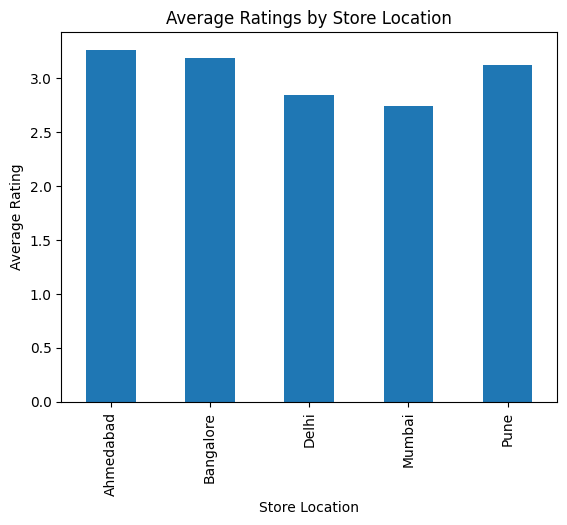

In [35]:
avg_rating.plot(kind="bar")

plt.title("Average Ratings by Store Location")
plt.xlabel("Store Location")
plt.ylabel("Average Rating")

plt.show()

### Create a pie chart for recommendation distribution.

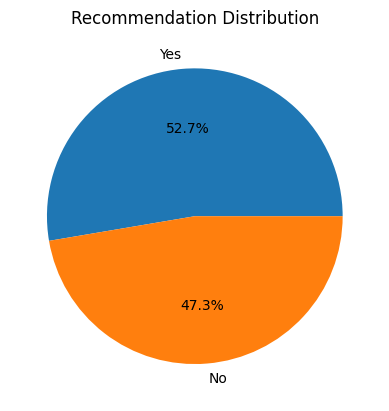

In [36]:
recommend_distribution = df["Recommend"].value_counts()

recommend_distribution.plot(kind="pie", autopct="%1.1f%%")

plt.title("Recommendation Distribution")

plt.ylabel("")

plt.show()

### Plot a line chart of total purchases over time.

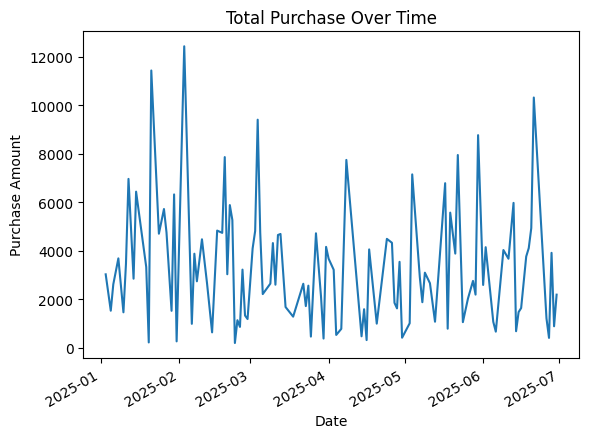

In [37]:
daily_sales = df.groupby("Visit_Date")["Purchase_Amount"].sum()

daily_sales.plot(kind="line")

plt.title("Total Purchase Over Time")
plt.xlabel("Date")
plt.ylabel("Purchase Amount")

plt.show()
          

## Seaborn Visualization

### Seaborn: Boxplot for Purchase_Amount by Store_Location.

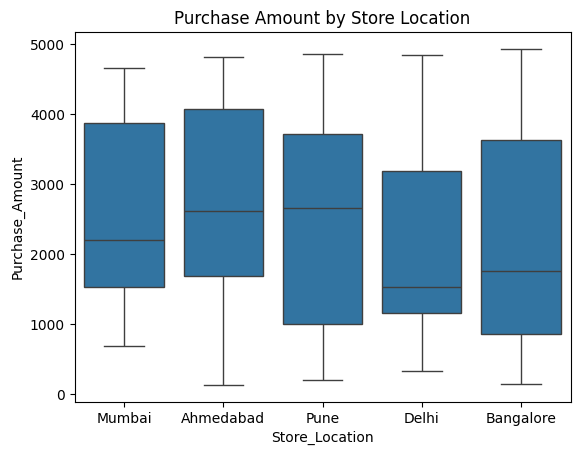

In [38]:
sns.boxplot(x="Store_Location", y="Purchase_Amount", data = df)

plt.title("Purchase Amount by Store Location")

plt.show()

### Seaborn: Heatmap showing correlation between numeric variables.

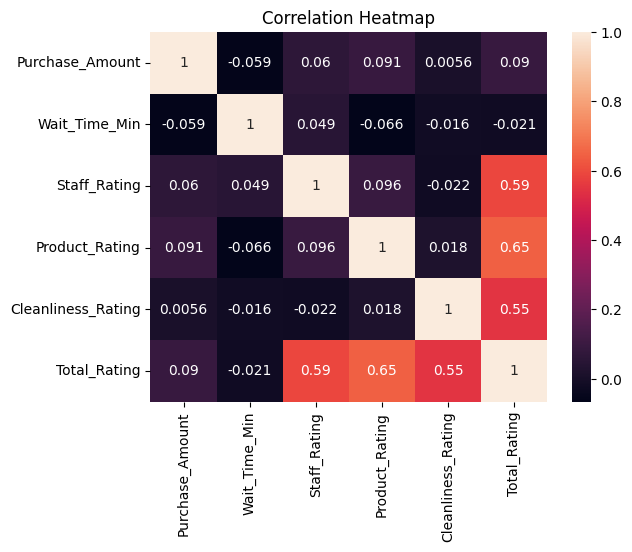

In [39]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

sns.heatmap(correlation_matrix, annot=True)

plt.title("Correlation Heatmap")

plt.show()